# Rollout Diagnostics

Deep dive into individual rollouts for 3 proteins with many long-range contacts.
For each protein: show what the model actually generates, annotate true vs false contacts,
and examine the spread of accuracy across rollouts.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
%matplotlib inline

RESULTS_PATH = "../../results/benchmark_exp5.jsonl"

# Pick 3 proteins with many long-range contacts (varied sizes)
TARGET_IDS = [
    "AF-A0A3P2RKZ8-F1",  # 497 res, 450 long-range
    "AF-A0A315SEF5-F1",  # 165 res, 151 long-range (smaller)
    "AF-A0A161VF79-F1",  # 653 res, 529 long-range (larger)
]

records = {}
with open(RESULTS_PATH) as f:
    for line in f:
        rec = json.loads(line)
        if rec["entry_id"] in TARGET_IDS:
            records[rec["entry_id"]] = rec

# Fall back to top-3 by long-range count if targets not found
if len(records) < 3:
    print(f"Only found {len(records)} target proteins, loading all and picking top 3")
    all_recs = []
    with open(RESULTS_PATH) as f:
        for line in f:
            all_recs.append(json.loads(line))
    all_recs.sort(key=lambda r: -sum(1 for c in r["gt_contacts"] if c[5]=="bin_lt4" and abs(c[1]-c[2])>=24))
    records = {r["entry_id"]: r for r in all_recs[:3]}

for eid, rec in records.items():
    gt = rec["gt_contacts"]
    lt4 = [c for c in gt if c[5]=="bin_lt4"]
    seps = [abs(c[1]-c[2]) for c in lt4]
    n_long = sum(1 for s in seps if s >= 24)
    print(f"{eid}: {rec['seq_len']} res, {len(lt4)} lt4 GT contacts, {n_long} long-range")

AF-A0A315SEF5-F1: 165 res, 458 lt4 GT contacts, 151 long-range
AF-A0A3P2RKZ8-F1: 497 res, 952 lt4 GT contacts, 450 long-range
AF-A0A161VF79-F1: 653 res, 928 lt4 GT contacts, 529 long-range


In [2]:
# Helper functions
def gt_pair_set(rec, min_sep=0):
    """Get GT lt4 pairs with minimum separation."""
    return {(min(c[1],c[2]), max(c[1],c[2])) 
            for c in rec["gt_contacts"] if c[5]=="bin_lt4" and abs(c[1]-c[2]) >= min_sep}

def rollout_pairs(rollout, min_sep=0):
    """Get lt4 pairs from a single rollout."""
    return {(min(c[1],c[2]), max(c[1],c[2])) 
            for c in rollout["contacts"] if c[5]=="bin_lt4" and abs(c[1]-c[2]) >= min_sep}

def rollout_stats(rollout, gt_set, min_sep=0):
    """Compute stats for a single rollout."""
    pred = rollout_pairs(rollout, min_sep)
    correct = pred & gt_set
    false_pos = pred - gt_set
    missed = gt_set - pred
    n = len(pred)
    prec = len(correct) / n if n else 0
    rec = len(correct) / len(gt_set) if gt_set else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    return {
        "n_pred": n, "n_correct": len(correct), "n_false_pos": len(false_pos),
        "n_missed": len(missed), "prec": prec, "rec": rec, "f1": f1,
    }

print("Helpers ready.")

Helpers ready.


In [3]:
# Per-protein deep dive
for eid, rec in records.items():
    seq_len = rec["seq_len"]
    gt_all = gt_pair_set(rec, min_sep=2)
    gt_short = gt_pair_set(rec, min_sep=6) - gt_pair_set(rec, min_sep=12)
    gt_medium = gt_pair_set(rec, min_sep=12) - gt_pair_set(rec, min_sep=24)
    gt_long = gt_pair_set(rec, min_sep=24)
    gt_6plus = gt_pair_set(rec, min_sep=6)
    
    print("\n" + "=" * 80)
    print(f"{eid} ({seq_len} residues)")
    print(f"GT contacts (lt4): {len(gt_all)} total, "
          f"short(6-12)={len(gt_short)}, med(12-24)={len(gt_medium)}, long(>=24)={len(gt_long)}")
    print("=" * 80)
    
    # Per-rollout breakdown (seq_only)
    print(f"\n{'':>4s} {'N_pred':>7s} {'N_lt4':>6s} | {'Prec':>6s} {'Rec':>6s} {'F1':>6s} | "
          f"{'S_prec':>6s} {'S_rec':>6s} | {'M_prec':>6s} {'M_rec':>6s} | {'L_prec':>6s} {'L_rec':>6s} | bins")
    print("-" * 110)
    
    rollouts = rec["seq_only"]
    per_rollout = []
    for ri, rollout in enumerate(rollouts):
        all_contacts = rollout["contacts"]
        bins = Counter(c[5] for c in all_contacts)
        
        s_all = rollout_stats(rollout, gt_6plus, min_sep=6)
        s_short = rollout_stats(rollout, gt_short, min_sep=6)
        # Hack: filter to 6-12 for short stats
        short_pred = {(min(c[1],c[2]),max(c[1],c[2])) for c in all_contacts 
                      if c[5]=="bin_lt4" and 6 <= abs(c[1]-c[2]) < 12}
        short_correct = len(short_pred & gt_short)
        s_p = short_correct/len(short_pred) if short_pred else 0
        s_r = short_correct/len(gt_short) if gt_short else 0
        
        med_pred = {(min(c[1],c[2]),max(c[1],c[2])) for c in all_contacts 
                    if c[5]=="bin_lt4" and 12 <= abs(c[1]-c[2]) < 24}
        med_correct = len(med_pred & gt_medium)
        m_p = med_correct/len(med_pred) if med_pred else 0
        m_r = med_correct/len(gt_medium) if gt_medium else 0
        
        long_pred = {(min(c[1],c[2]),max(c[1],c[2])) for c in all_contacts 
                     if c[5]=="bin_lt4" and abs(c[1]-c[2]) >= 24}
        long_correct = len(long_pred & gt_long)
        l_p = long_correct/len(long_pred) if long_pred else 0
        l_r = long_correct/len(gt_long) if gt_long else 0
        
        n_lt4 = sum(1 for c in all_contacts if c[5]=="bin_lt4")
        bin_str = f"lt4={bins.get('bin_lt4',0)} 4-12={bins.get('bin_4_12',0)} gt12={bins.get('bin_gt12',0)}"
        
        print(f"R{ri:2d} {len(all_contacts):>7d} {n_lt4:>6d} | "
              f"{s_all['prec']:>5.1%} {s_all['rec']:>5.1%} {s_all['f1']:>5.3f} | "
              f"{s_p:>5.1%} {s_r:>5.1%} | {m_p:>5.1%} {m_r:>5.1%} | {l_p:>5.1%} {l_r:>5.1%} | {bin_str}")
        
        per_rollout.append({
            "short_prec": s_p, "short_rec": s_r,
            "med_prec": m_p, "med_rec": m_r,
            "long_prec": l_p, "long_rec": l_r,
            "all_prec": s_all["prec"], "all_rec": s_all["rec"],
            "n_short": len(short_pred), "n_med": len(med_pred), "n_long": len(long_pred),
        })


AF-A0A315SEF5-F1 (165 residues)
GT contacts (lt4): 458 total, short(6-12)=40, med(12-24)=65, long(>=24)=151

      N_pred  N_lt4 |   Prec    Rec     F1 | S_prec  S_rec | M_prec  M_rec | L_prec  L_rec | bins
--------------------------------------------------------------------------------------------------------------
R 0     573    421 |  6.3%  5.1% 0.056 | 12.1% 10.0% |  7.9%  4.6% |  4.4%  4.0% | lt4=421 4-12=105 gt12=47
R 1     573    419 |  4.7%  3.5% 0.040 | 10.0% 10.0% |  5.3%  3.1% |  2.7%  2.0% | lt4=419 4-12=106 gt12=48
R 2     395    293 |  9.4%  4.7% 0.062 |  3.7%  2.5% | 10.0%  7.7% | 11.8%  4.0% | lt4=293 4-12=68 gt12=34
R 3     573    423 |  5.2%  3.1% 0.039 | 16.0% 10.0% | 25.0%  6.2% |  0.0%  0.0% | lt4=423 4-12=108 gt12=42
R 4     573    422 |  4.9%  3.5% 0.041 | 12.5%  5.0% | 12.8%  9.2% |  0.8%  0.7% | lt4=422 4-12=100 gt12=51
R 5     573    420 |  4.8%  3.1% 0.038 | 16.7% 10.0% |  3.1%  1.5% |  2.7%  2.0% | lt4=420 4-12=102 gt12=51
R 6     573    421 |  7.4%  6.6% 0

In [4]:
# Annotated contact dump for first protein, first rollout
eid = list(records.keys())[0]
rec = records[eid]
gt_set = gt_pair_set(rec, min_sep=2)
rollout = rec["seq_only"][0]

print(f"\nAnnotated contacts: {eid}, Rollout 0")
print(f"{'Idx':>4s} {'Corr':>5s} {'p1':>4s} {'p2':>4s} {'a1':>5s} {'a2':>5s} {'bin':>10s} {'sep':>4s} {'Match':>6s}")
print("-" * 55)

contacts = rollout["contacts"]
n_true = 0
n_false = 0
for i, c in enumerate(contacts):
    is_corr, p1, p2, a1, a2, bin_tok = c
    pair = (min(p1, p2), max(p1, p2))
    sep = abs(p1 - p2)
    match = pair in gt_set and bin_tok == "bin_lt4"
    if match:
        n_true += 1
    else:
        n_false += 1
    corr_str = "corr" if is_corr else ""
    match_str = "TRUE" if match else "false"
    
    if i < 50 or (i < 200 and i % 10 == 0) or i % 50 == 0:
        print(f"{i:4d} {corr_str:>5s} {p1:>4d} {p2:>4d} {a1:>5s} {a2:>5s} {bin_tok:>10s} {sep:>4d} {match_str:>6s}")
    elif i == 50:
        print(f"  ... (showing every 10th until 200, then every 50th)")

print(f"\nTotal: {len(contacts)} contacts, {n_true} true, {n_false} false")

# Break down false positives
fp_lt4 = [(c, (min(c[1],c[2]),max(c[1],c[2]))) for c in contacts 
          if c[5]=="bin_lt4" and (min(c[1],c[2]),max(c[1],c[2])) not in gt_set]
fp_other = [(c, (min(c[1],c[2]),max(c[1],c[2]))) for c in contacts 
            if c[5]!="bin_lt4"]
print(f"\nFalse positives: {len(fp_lt4)} bin_lt4 pairs not in GT")
print(f"Non-lt4 contacts: {len(fp_other)} (bin_4_12 or bin_gt12 — these are negatives by design)")


Annotated contacts: AF-A0A315SEF5-F1, Rollout 0
 Idx  Corr   p1   p2    a1    a2        bin  sep  Match
-------------------------------------------------------
   0         13  113   CD2    CB    bin_lt4  100  false
   1         54   56     C     N    bin_lt4    2   TRUE
   2        120  145     C     C   bin_4_12   25  false
   3         53   62     N     O    bin_lt4    9  false
   4         65   92     N     O    bin_lt4   27  false
   5        111  110     O     N    bin_lt4    1  false
   6          9   53     O     O   bin_gt12   44  false
   7         85   88   CD2   CE1    bin_lt4    3   TRUE
   8         57   88   CG1   CE1    bin_lt4   31  false
   9         85  112   CD1     O   bin_gt12   27  false
  10         38   40     C     N    bin_lt4    2   TRUE
  11         11  150     C     N   bin_4_12  139  false
  12         89   91     O     N    bin_lt4    2   TRUE
  13         86  117    CB    CA   bin_gt12   31  false
  14        144  146     O     N    bin_lt4    2   TRUE

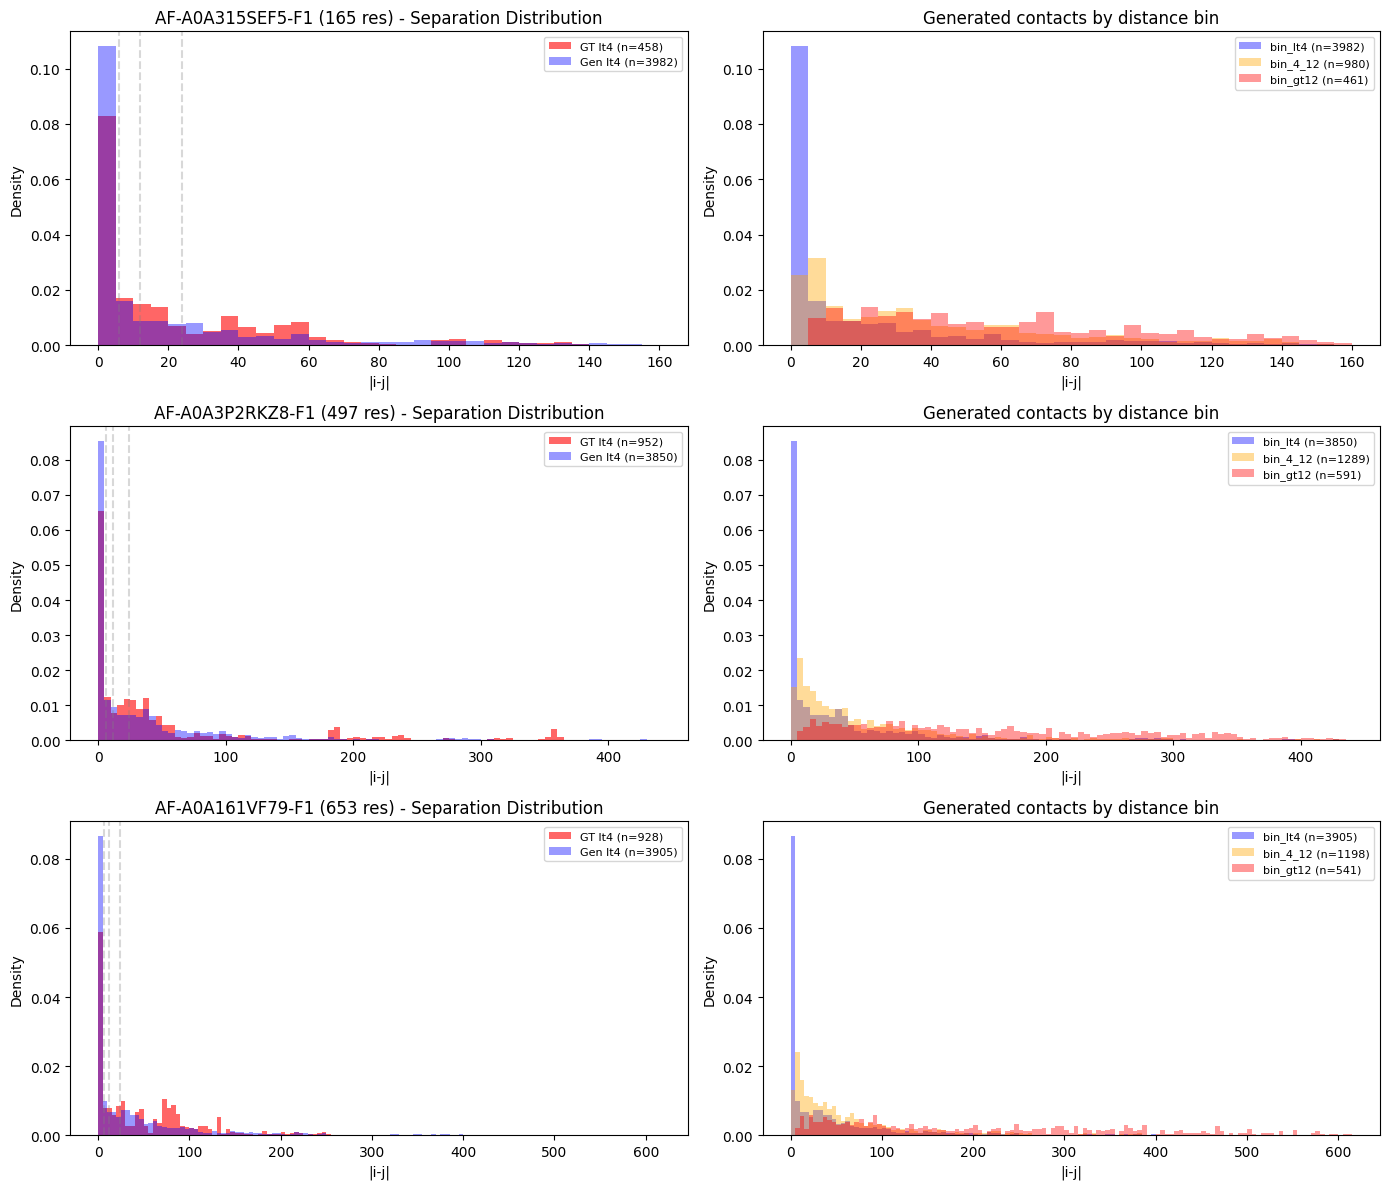

In [5]:
# Separation distribution: what does the model generate vs GT?
fig, axes = plt.subplots(len(records), 2, figsize=(14, 4*len(records)))
if len(records) == 1:
    axes = axes.reshape(1, -1)

for pi, (eid, rec) in enumerate(records.items()):
    gt = rec["gt_contacts"]
    gt_lt4_seps = [abs(c[1]-c[2]) for c in gt if c[5]=="bin_lt4" and abs(c[1]-c[2]) >= 2]
    
    # Aggregate all rollouts
    gen_lt4_seps = []
    gen_other_seps = []
    for rollout in rec["seq_only"]:
        for c in rollout["contacts"]:
            sep = abs(c[1] - c[2])
            if c[5] == "bin_lt4":
                gen_lt4_seps.append(sep)
            else:
                gen_other_seps.append(sep)
    
    # Histogram of separations
    ax = axes[pi, 0]
    bins = np.arange(0, max(max(gt_lt4_seps, default=1), max(gen_lt4_seps, default=1)) + 5, 5)
    ax.hist(gt_lt4_seps, bins=bins, alpha=0.6, color="red", label=f"GT lt4 (n={len(gt_lt4_seps)})", density=True)
    ax.hist(gen_lt4_seps, bins=bins, alpha=0.4, color="blue", label=f"Gen lt4 (n={len(gen_lt4_seps)})", density=True)
    ax.set_xlabel("|i-j|")
    ax.set_ylabel("Density")
    ax.set_title(f"{eid} ({rec['seq_len']} res) - Separation Distribution")
    ax.legend(fontsize=8)
    ax.axvline(6, color="grey", linestyle="--", alpha=0.3)
    ax.axvline(12, color="grey", linestyle="--", alpha=0.3)
    ax.axvline(24, color="grey", linestyle="--", alpha=0.3)
    
    # Generated bin distribution by separation
    ax = axes[pi, 1]
    all_seps_by_bin = defaultdict(list)
    for rollout in rec["seq_only"]:
        for c in rollout["contacts"]:
            all_seps_by_bin[c[5]].append(abs(c[1] - c[2]))
    for bin_name, color in [("bin_lt4", "blue"), ("bin_4_12", "orange"), ("bin_gt12", "red")]:
        if bin_name in all_seps_by_bin:
            ax.hist(all_seps_by_bin[bin_name], bins=bins, alpha=0.4, color=color,
                    label=f"{bin_name} (n={len(all_seps_by_bin[bin_name])})", density=True)
    ax.set_xlabel("|i-j|")
    ax.set_ylabel("Density")
    ax.set_title(f"Generated contacts by distance bin")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1903083/4022851593.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Short\n(6-12)", "Medium\n(12-24)", "Long\n(>=24)"], patch_artist=True)
/tmp/ipykernel_1903083/4022851593.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Short\n(6-12)", "Medium\n(12-24)", "Long\n(>=24)"], patch_artist=True)
/tmp/ipykernel_1903083/4022851593.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Short\n(6-12)", "Medium\n(12-24)", "Long\n(>=24)"], patch_artist=True)
/tmp/ipykernel_1903083/4022851593.py:38: MatplotlibDepreca

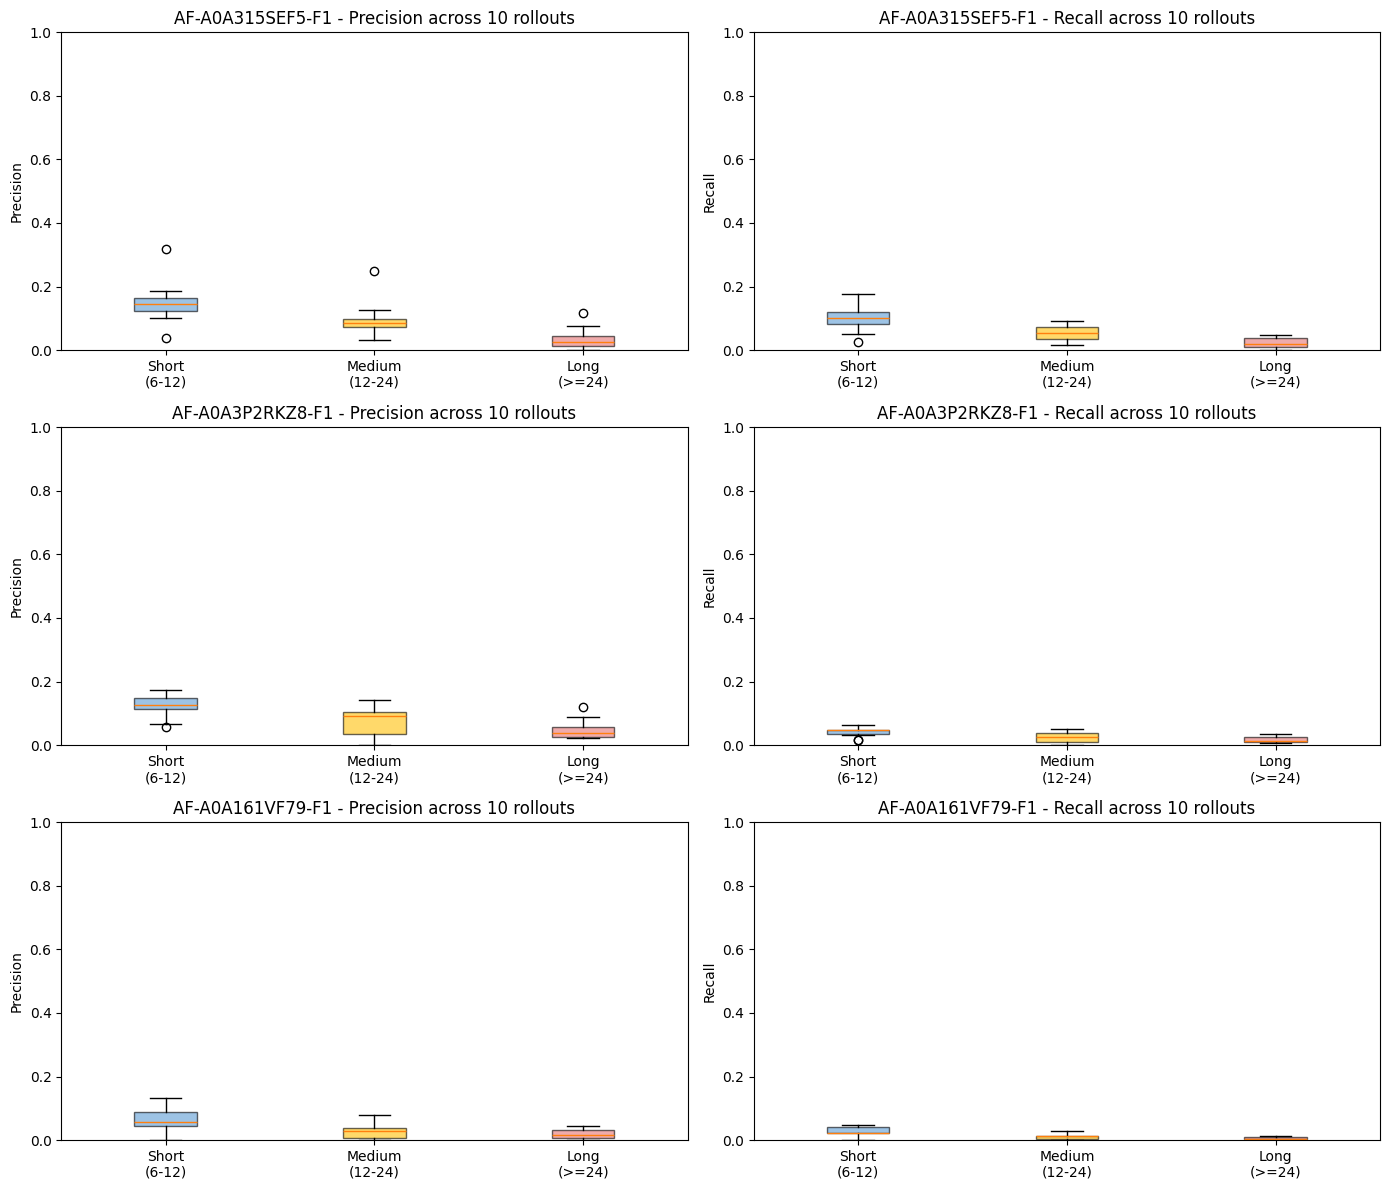

In [6]:
# Per-rollout accuracy spread
fig, axes = plt.subplots(len(records), 2, figsize=(14, 4*len(records)))
if len(records) == 1:
    axes = axes.reshape(1, -1)

for pi, (eid, rec) in enumerate(records.items()):
    gt_s = gt_pair_set(rec, min_sep=6) - gt_pair_set(rec, min_sep=12)
    gt_m = gt_pair_set(rec, min_sep=12) - gt_pair_set(rec, min_sep=24)
    gt_l = gt_pair_set(rec, min_sep=24)
    
    rollout_precs = {"short": [], "medium": [], "long": []}
    rollout_recs = {"short": [], "medium": [], "long": []}
    
    for rollout in rec["seq_only"]:
        contacts = rollout["contacts"]
        for range_name, min_sep, max_sep, gt_set in [
            ("short", 6, 12, gt_s), ("medium", 12, 24, gt_m), ("long", 24, None, gt_l)]:
            pred = {(min(c[1],c[2]),max(c[1],c[2])) for c in contacts
                    if c[5]=="bin_lt4" and abs(c[1]-c[2]) >= min_sep 
                    and (max_sep is None or abs(c[1]-c[2]) < max_sep)}
            correct = len(pred & gt_set)
            rollout_precs[range_name].append(correct/len(pred) if pred else 0)
            rollout_recs[range_name].append(correct/len(gt_set) if gt_set else 0)
    
    # Box plots of precision and recall across rollouts
    ax = axes[pi, 0]
    data = [rollout_precs["short"], rollout_precs["medium"], rollout_precs["long"]]
    bp = ax.boxplot(data, labels=["Short\n(6-12)", "Medium\n(12-24)", "Long\n(>=24)"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#5C9BD5", "#FFC107", "#E57373"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("Precision")
    ax.set_title(f"{eid} - Precision across {len(rec['seq_only'])} rollouts")
    ax.set_ylim(0, 1)
    
    ax = axes[pi, 1]
    data = [rollout_recs["short"], rollout_recs["medium"], rollout_recs["long"]]
    bp = ax.boxplot(data, labels=["Short\n(6-12)", "Medium\n(12-24)", "Long\n(>=24)"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#5C9BD5", "#FFC107", "#E57373"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("Recall")
    ax.set_title(f"{eid} - Recall across {len(rec['seq_only'])} rollouts")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [7]:
# Consensus analysis: which contacts are consistently predicted?
for eid, rec in records.items():
    seq_len = rec["seq_len"]
    gt_l = gt_pair_set(rec, min_sep=24)
    gt_s = gt_pair_set(rec, min_sep=6) - gt_pair_set(rec, min_sep=12)
    
    # Count how often each pair appears across rollouts
    pair_freq = defaultdict(int)
    n_rollouts = len(rec["seq_only"])
    for rollout in rec["seq_only"]:
        for c in rollout["contacts"]:
            if c[5] == "bin_lt4":
                pair = (min(c[1],c[2]), max(c[1],c[2]))
                pair_freq[pair] += 1
    
    # Separate into ranges
    short_freqs = {p: f/n_rollouts for p, f in pair_freq.items() if 6 <= abs(p[0]-p[1]) < 12}
    long_freqs = {p: f/n_rollouts for p, f in pair_freq.items() if abs(p[0]-p[1]) >= 24}
    
    print(f"\n{'=' * 70}")
    print(f"{eid}: Consensus analysis ({n_rollouts} rollouts)")
    print(f"{'=' * 70}")
    
    for range_name, freqs, gt_set in [("Short (6-12)", short_freqs, gt_s), 
                                       ("Long (>=24)", long_freqs, gt_l)]:
        if not freqs:
            print(f"\n  {range_name}: no predictions")
            continue
        
        # Sort by frequency
        sorted_pairs = sorted(freqs.items(), key=lambda x: -x[1])
        
        # Precision at different frequency thresholds
        print(f"\n  {range_name}: {len(freqs)} unique pairs predicted, {len(gt_set)} GT")
        for thresh in [0.1, 0.3, 0.5, 0.7, 0.9]:
            above = {p for p, f in freqs.items() if f >= thresh}
            correct = len(above & gt_set)
            prec = correct / len(above) if above else 0
            rec_val = correct / len(gt_set) if gt_set else 0
            print(f"    freq >= {thresh}: {len(above):4d} pred, {correct:4d} correct, "
                  f"P={prec:.1%} R={rec_val:.1%}")
        
        # Show top-20 most frequent predictions with GT match
        print(f"\n    Top 20 most frequent:")
        for pair, freq in sorted_pairs[:20]:
            match = "TRUE" if pair in gt_set else "false"
            print(f"      ({pair[0]:>3d}, {pair[1]:>3d}) sep={abs(pair[0]-pair[1]):>3d}  "
                  f"freq={freq:.0%}  {match}")


AF-A0A315SEF5-F1: Consensus analysis (10 rollouts)

  Short (6-12): 209 unique pairs predicted, 40 GT
    freq >= 0.1:  209 pred,   23 correct, P=11.0% R=57.5%
    freq >= 0.3:   18 pred,    4 correct, P=22.2% R=10.0%
    freq >= 0.5:    2 pred,    1 correct, P=50.0% R=2.5%
    freq >= 0.7:    0 pred,    0 correct, P=0.0% R=0.0%
    freq >= 0.9:    0 pred,    0 correct, P=0.0% R=0.0%

    Top 20 most frequent:
      ( 22,  30) sep=  8  freq=50%  false
      ( 41,  48) sep=  7  freq=50%  TRUE
      (113, 122) sep=  9  freq=40%  false
      (113, 119) sep=  6  freq=30%  TRUE
      (112, 121) sep=  9  freq=30%  false
      (111, 122) sep= 11  freq=30%  false
      ( 54,  62) sep=  8  freq=30%  false
      (113, 120) sep=  7  freq=30%  false
      ( 53,  63) sep= 10  freq=30%  false
      ( 57,  67) sep= 10  freq=30%  false
      ( 54,  63) sep=  9  freq=30%  false
      (113, 121) sep=  8  freq=30%  false
      (112, 123) sep= 11  freq=30%  false
      (115, 121) sep=  6  freq=30%  false

In [8]:
# How many distinct long-range pairs does the model ever predict (across all rollouts)?
# And what fraction of GT long-range pairs are NEVER predicted?
for eid, rec in records.items():
    gt_l = gt_pair_set(rec, min_sep=24)
    
    all_predicted_long = set()
    for rollout in rec["seq_only"]:
        for c in rollout["contacts"]:
            if c[5] == "bin_lt4" and abs(c[1]-c[2]) >= 24:
                all_predicted_long.add((min(c[1],c[2]), max(c[1],c[2])))
    
    ever_correct = all_predicted_long & gt_l
    never_predicted = gt_l - all_predicted_long
    
    print(f"\n{eid}:")
    print(f"  GT long-range pairs: {len(gt_l)}")
    print(f"  Unique long-range pairs ever predicted: {len(all_predicted_long)}")
    print(f"  Correct (predicted & in GT): {len(ever_correct)} ({100*len(ever_correct)/len(gt_l):.0f}% of GT)")
    print(f"  Never predicted: {len(never_predicted)} ({100*len(never_predicted)/len(gt_l):.0f}% of GT)")
    print(f"  False positives (predicted but not in GT): {len(all_predicted_long - gt_l)}")
    
    # What separations are the never-predicted contacts?
    if never_predicted:
        never_seps = [abs(p[0]-p[1]) for p in never_predicted]
        predicted_seps = [abs(p[0]-p[1]) for p in ever_correct]
        print(f"  Never-predicted separations: mean={np.mean(never_seps):.0f}, "
              f"median={np.median(never_seps):.0f}, range={min(never_seps)}-{max(never_seps)}")
        if predicted_seps:
            print(f"  Correctly-predicted separations: mean={np.mean(predicted_seps):.0f}, "
                  f"median={np.median(predicted_seps):.0f}, range={min(predicted_seps)}-{max(predicted_seps)}")


AF-A0A315SEF5-F1:
  GT long-range pairs: 151
  Unique long-range pairs ever predicted: 965
  Correct (predicted & in GT): 31 (21% of GT)
  Never predicted: 120 (79% of GT)
  False positives (predicted but not in GT): 934
  Never-predicted separations: mean=59, median=52, range=24-136
  Correctly-predicted separations: mean=48, median=38, range=24-123

AF-A0A3P2RKZ8-F1:
  GT long-range pairs: 450
  Unique long-range pairs ever predicted: 1472
  Correct (predicted & in GT): 59 (13% of GT)
  Never predicted: 391 (87% of GT)
  False positives (predicted but not in GT): 1413
  Never-predicted separations: mean=108, median=55, range=24-362
  Correctly-predicted separations: mean=49, median=36, range=24-271

AF-A0A161VF79-F1:
  GT long-range pairs: 529
  Unique long-range pairs ever predicted: 1632
  Correct (predicted & in GT): 30 (6% of GT)
  Never predicted: 499 (94% of GT)
  False positives (predicted but not in GT): 1602
  Never-predicted separations: mean=87, median=76, range=24-250
  